In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.feature_selection import RFECV
import xgboost as xgb
from xgboost import cv, DMatrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
data = pd.read_csv("../Data/diabetes_prediction_dataset_2.csv")
data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [5]:
data.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [6]:
data.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [10]:
data.duplicated().sum()

3854

In [11]:
data = data.drop_duplicates()

In [14]:
data.duplicated().sum()

0

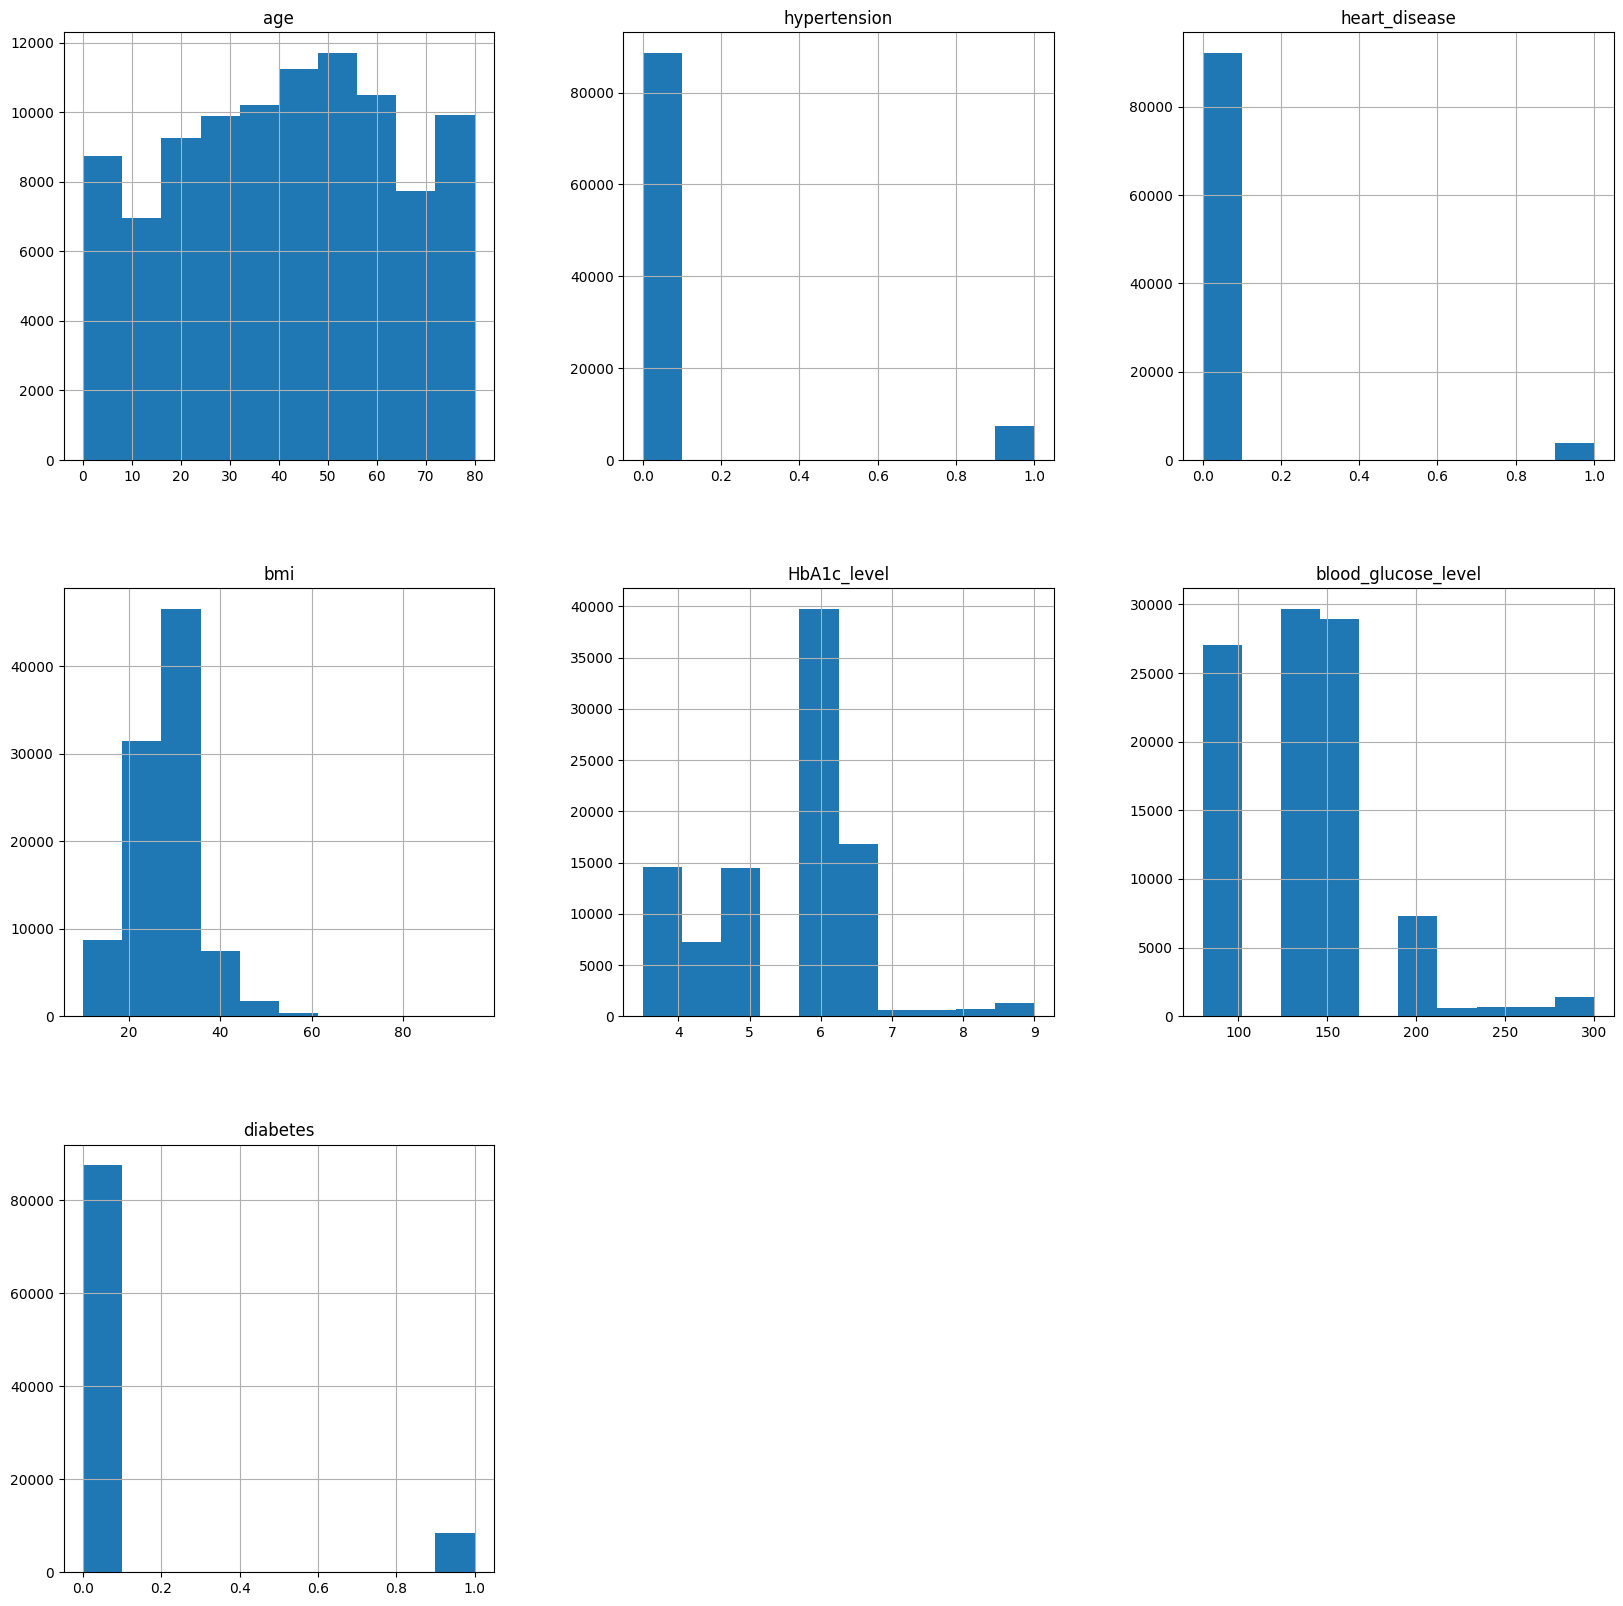

In [15]:
data.hist(figsize=[20,20])
plt.show()

<Axes: >

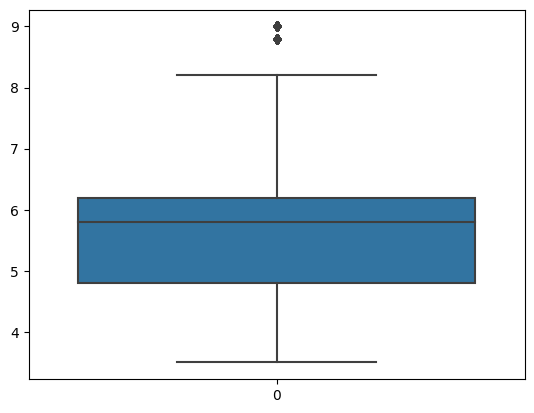

In [31]:
sns.boxplot(data['HbA1c_level'])

<Axes: >

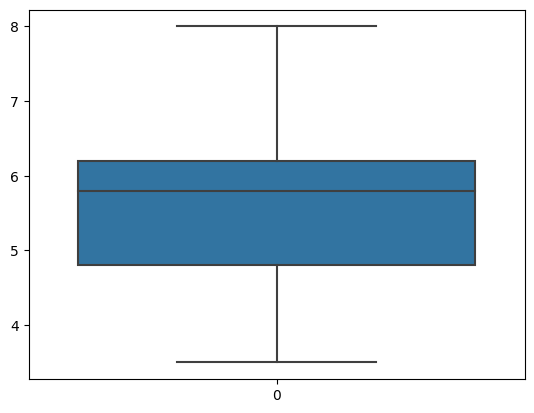

In [33]:
data['HbA1c_level']= np.where(data['HbA1c_level']>8, 8, data['HbA1c_level'])
sns.boxplot(data['HbA1c_level'])

<Axes: >

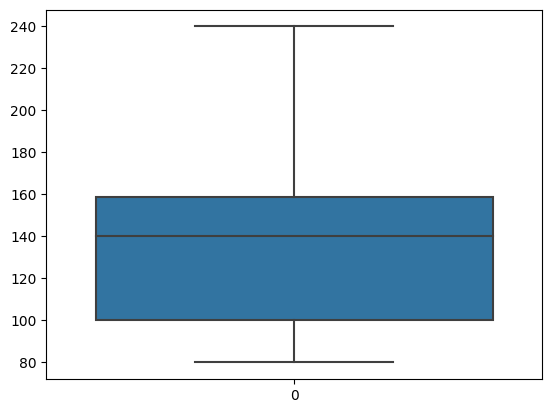

In [30]:
# Penanganan Outlier

data['blood_glucose_level']= np.where(data['blood_glucose_level']>240, 240, data['blood_glucose_level'])
# cek kembali
sns.boxplot(data["blood_glucose_level"])

In [34]:
data.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.518965,137.365153,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.035790,38.201293,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,8.000000,240.000000,1.000000


In [35]:
# Encoding Variabel 
label_encoders = {}
categorical_columns = ['gender', 'smoking_history']

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

for column in categorical_columns:
    label_encoders[column] = LabelEncoder()  # Membuat instance LabelEncoder untuk setiap kolom
    data[column] = label_encoders[column].fit_transform(data[column])  # Transformasi data

In [41]:
X = data.drop(['diabetes'], axis=1)
y = data['diabetes']

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [45]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [64]:
ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])

In [65]:
ratio

10.334512231063956

In [66]:
xg = xgb.XGBClassifier(n_estimators = 100, scale_pos_weight=ratio)
xg.fit(X_train_scaled, y_train)
xg_preds= xg.predict(X_test_scaled)
print(classification_report(y_test, xg_preds))

              precision    recall  f1-score   support

           0       0.99      0.92      0.95     17534
           1       0.51      0.89      0.65      1696

    accuracy                           0.91     19230
   macro avg       0.75      0.90      0.80     19230
weighted avg       0.95      0.91      0.92     19230



In [68]:
# Inisialisasi data dan parameter
params = {
    "objective": "binary:logistic",
    "colsample_bytree": 0.3,
    "learning_rate": 0.1,
    "max_depth": 10,
    "alpha": 10,
    "scale_pos_weight": ratio
}
data_dmatrix = DMatrix(data=X_train_scaled, label=y_train)  # Ganti X_train dan y_train sesuai data Anda

# List untuk menyimpan hasil dari masing-masing nfold
nfolds = [3, 5, 10]
best_results = {}

for n in nfolds:
    # Menjalankan cross-validation untuk setiap nilai nfold
    xgb_cv = cv(
        dtrain=data_dmatrix,
        params=params,
        nfold=n,
        num_boost_round=50,  # Jumlah iterasi yang digunakan selama cross-validation
        early_stopping_rounds=10,
        metrics="auc",
        as_pandas=True,
        seed=42,
    )
    
    # Menyimpan iterasi terbaik berdasarkan AUC
    best_iteration = xgb_cv['test-auc-mean'].idxmax()
    best_auc = xgb_cv['test-auc-mean'].iloc[best_iteration]
    
    # Menyimpan hasil terbaik berdasarkan AUC
    best_results[n] = {
        'best_iteration': best_iteration,
        'best_auc': best_auc,
        'xgb_cv': xgb_cv
    }
    
    print(f"nfold = {n}")
    print(f"Best AUC: {best_auc} at iteration {best_iteration}")
    print("="*50)

# Menentukan nfold dengan AUC terbaik
best_nfold = max(best_results, key=lambda x: best_results[x]['best_auc'])
print(f"nfold terbaik berdasarkan AUC adalah: {best_nfold} dengan AUC {best_results[best_nfold]['best_auc']}")

nfold = 3
Best AUC: 0.9718449999357794 at iteration 20
nfold = 5
Best AUC: 0.9691816565323966 at iteration 10
nfold = 10
Best AUC: 0.9753970992636315 at iteration 49
nfold terbaik berdasarkan AUC adalah: 10 dengan AUC 0.9753970992636315


### Confusion Matrix

In [69]:
# Membuat model terbaik berdasarkan nfold terbaik dan iterasi terbaik
best_iteration = best_results[best_nfold]['best_iteration']
params['n_estimators'] = best_iteration  # Set n_estimators ke iterasi terbaik

In [70]:
# Latih model dengan data pelatihan
model_best = xgb.XGBClassifier(**params)
model_best.fit(X_train, y_train)

XGBClassifier(alpha=10, base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.3,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constraints='',
              learning_rate=0.1, max_bin=256, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=10, max_leaves=0, min_child_weight=1,
              missing=nan, monotone_constraints='()', n_estimators=49, n_jobs=0,
              num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=10, ...)

In [71]:
# Prediksi data uji
y_pred_best = model_best.predict(X_test)

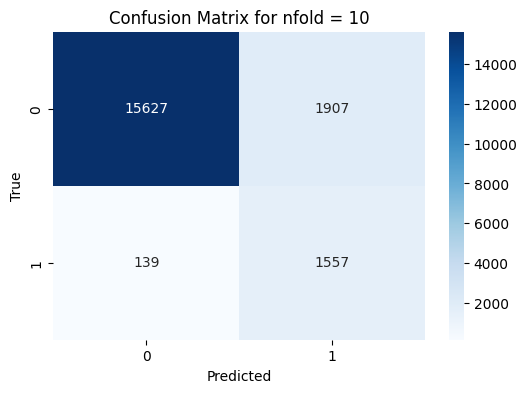

In [72]:
# Menghitung dan menampilkan confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_best)

# Visualisasi confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix for nfold = {best_nfold}')
plt.show()

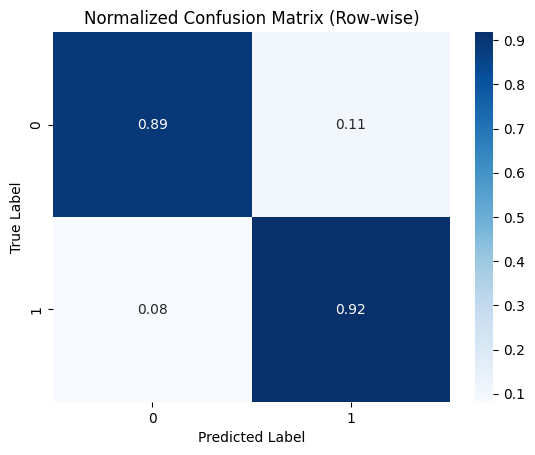

In [73]:
##Membuat confussion matrix yang dinormalisasi
def normalize_confusion_matrix(cm, norm='true'):
    if norm == 'true':
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    elif norm == 'pred':
        cm_normalized = cm.astype('float') / cm.sum(axis=0)[np.newaxis, :]
    elif norm == 'all':
        cm_normalized = cm.astype('float') / cm.sum()
    else:
        raise ValueError("Unknown normalization type. Use 'true', 'pred', or 'all'.")
    
    return cm_normalized

cm = confusion_matrix(y_test, y_pred_best)
cm_normalized = normalize_confusion_matrix(cm, norm='true')

# Plotting
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues')
plt.title('Normalized Confusion Matrix (Row-wise)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

c:\Users\HAJRAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='diabetes', ylabel='Count'>

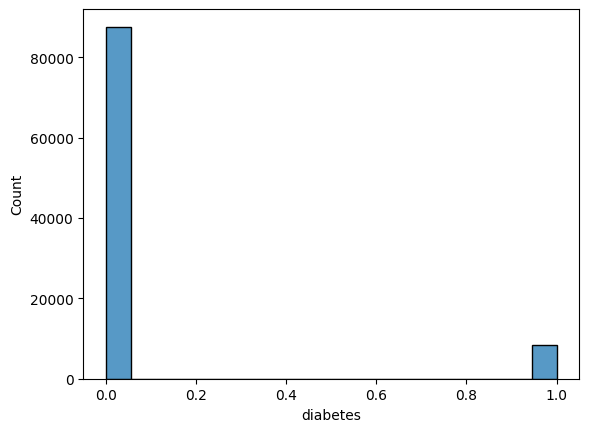

In [55]:
sns.histplot(data['diabetes'])